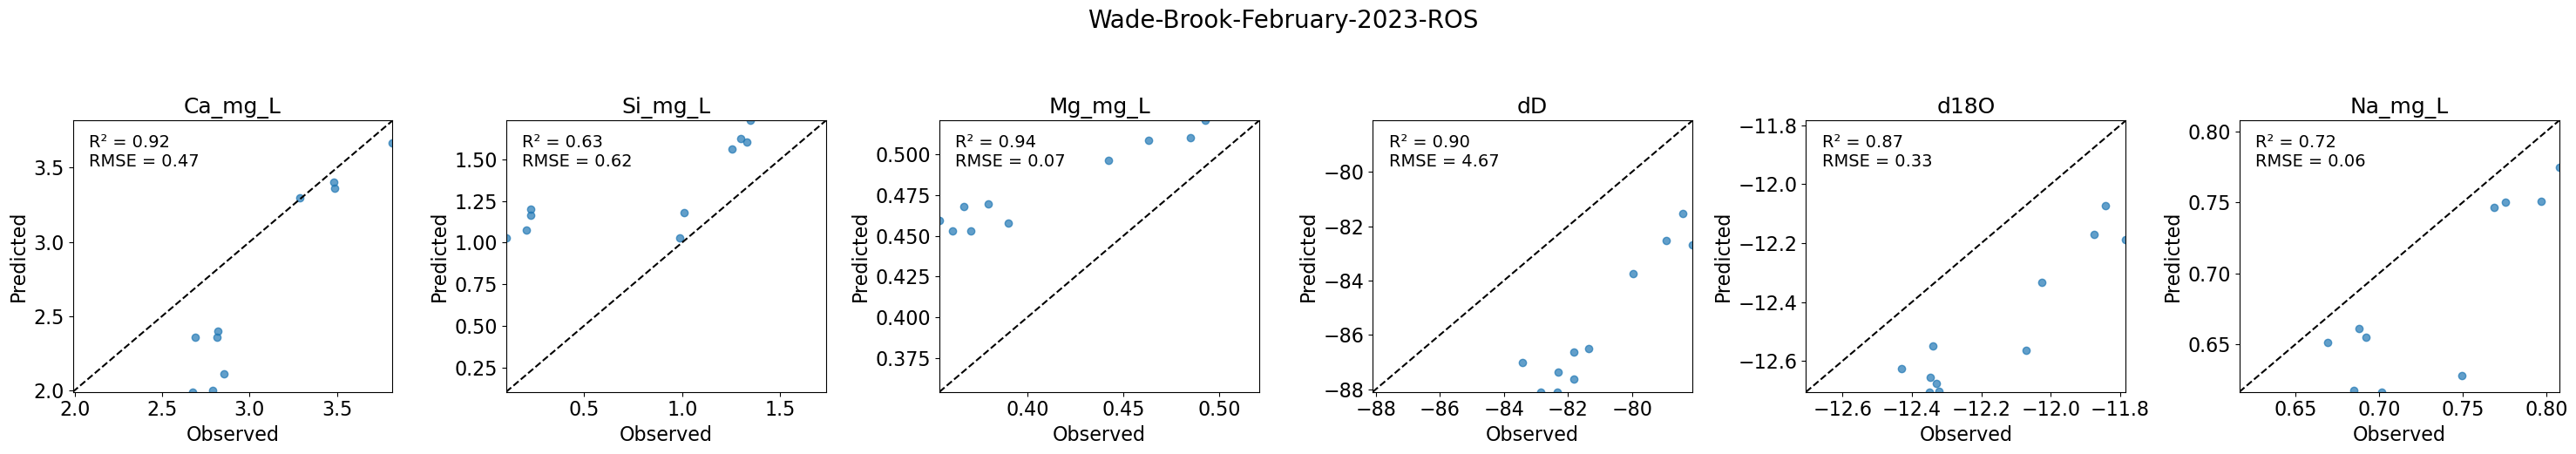

✅ Figure saved to output/EMMA-error-plots/Wade-Brook-February-2023-ROS.png


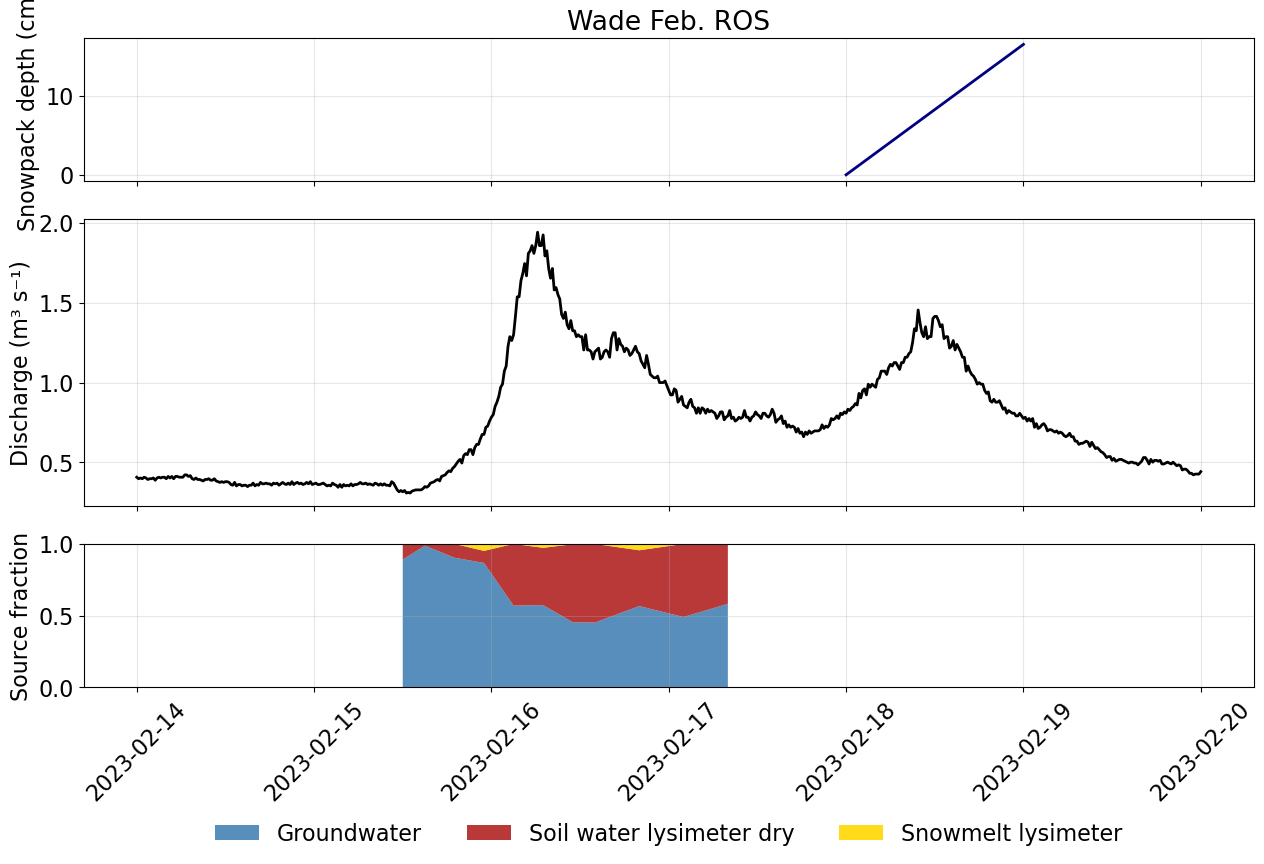

In [14]:
import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_emma as em
importlib.reload(em)

# Load the full RI25 dataset
df = pd.read_csv("/home/millieginty/OneDrive/git-repos/EMMA/data/newrnet-chemistry/RI23/RI23-IC-ICP-isotope-toc-joined-Wade.csv")

####################
# Wade RI23 events #
####################

# Event A
# Wade February ROS event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23
    # RI23-5005 Snowmelt lysimeter 2/15
    # RI23-1034 Pre-event baseflow, labeled as GW in Wade index

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_febros_fractions_df, wade_febros_scaler, wade_febros_pca, wade_febros_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-02-14 00:00:00",
    end_date="2023-02-20 00:00:00",
    endmember_ids=[
                   #"RI23-5018", "RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   "RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples        
                   "RI23-5000", # SWL D February 15 2023
                   "RI23-5005", # Snowmelt lysimeter 2/15
                  ], 
)

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']
#wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O']

# Call the prediction function
wade_febros_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_febros_fractions_df,
    endmembers_df=wade_febros_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted("Wade-Brook-February-2023-ROS", wade_febros_predicted, df, wade_tracers)

em.plot_emma_fractions_with_hydrograph(
    fractions_df= wade_febros_fractions_df,
    discharge_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    snowpack_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414.csv",
    snowpack_time_col="datetime",
    start_date="2023-02-14 00:00:00",
    end_date="2023-02-20 00:00:00",
    site="Wade",
    title="Wade Feb. ROS"
)

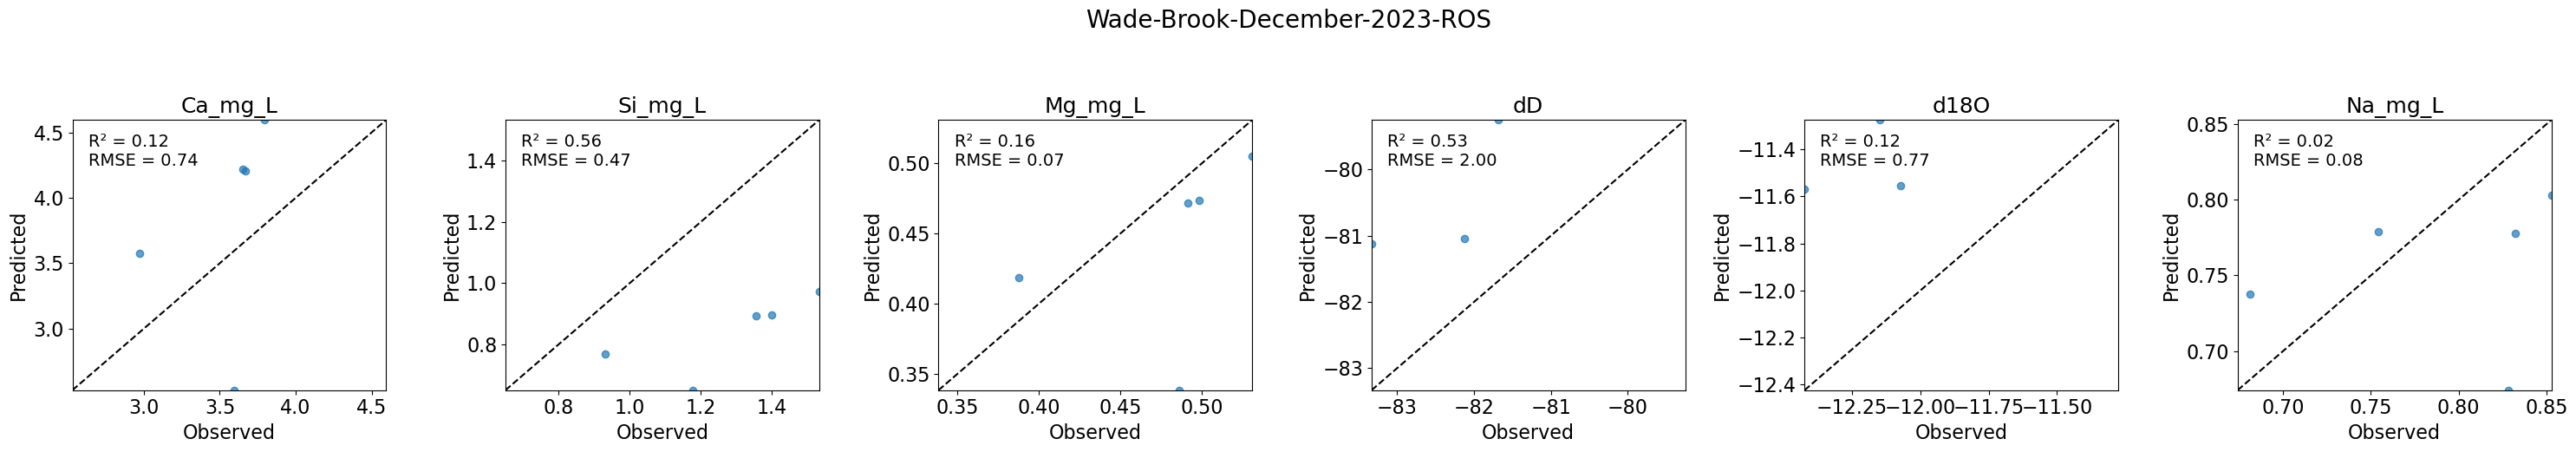

✅ Figure saved to output/EMMA-error-plots/Wade-Brook-December-2023-ROS.png


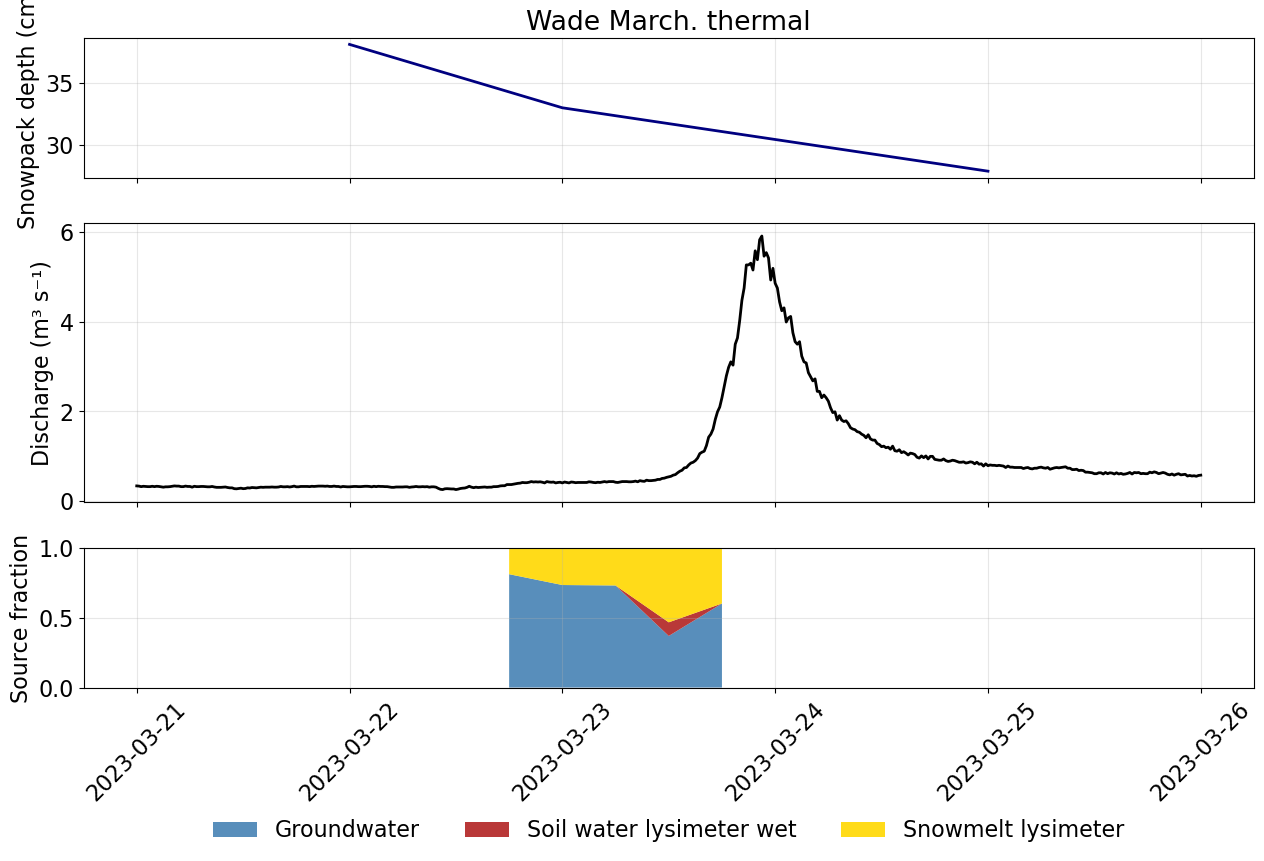

In [6]:
import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_emma as em
importlib.reload(em)

# Load the full RI25 dataset
df = pd.read_csv("/home/millieginty/OneDrive/git-repos/EMMA/data/newrnet-chemistry/RI23/RI23-IC-ICP-isotope-toc-joined-Wade.csv")

####################
# Wade RI23 events #
####################

# Event B
# Wade March 2023 thermal event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23 (removed)
    # RI23-5005 Snowmelt lysimeter 2/15 (removed)
    # RI23-5009 Soil water lysimeter dry 3/16 (removed)
    # RI23-1063 Snowmelt lysimeter 3/28
    # RI23-1034 Baseflow 3/22 (labeled as GW)
    # RI23-5011 Soil water lysimeter wet 4/12

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_decros_fractions_df, wade_decros_scaler, wade_decros_pca, wade_decros_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
    endmember_ids=["RI23-5018", "RI23-5006", # Groundwater samples from Wade wells
                   "RI23-1034", # Baseflow from 2023
                   "RI22-0860", "RI22-0859", # RI22 Groundwater samples
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # RI25 Baseflow samples
                   "RI23-5005", "RI23-1063", "RI23-1098", # Snowmelt lysimeter samples
                   "RI23-5011"]) # Soil water lysimeter sample

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']

# Call the prediction function
wade_decros_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_decros_fractions_df,
    endmembers_df=wade_decros_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted("Wade-Brook-December-2023-ROS", wade_decros_predicted, df, wade_tracers)

em.plot_emma_fractions_with_hydrograph(
    fractions_df= wade_decros_fractions_df,
    discharge_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    snowpack_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414.csv",
    snowpack_time_col="datetime",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
    site="Wade",
    title="Wade March. thermal"
)

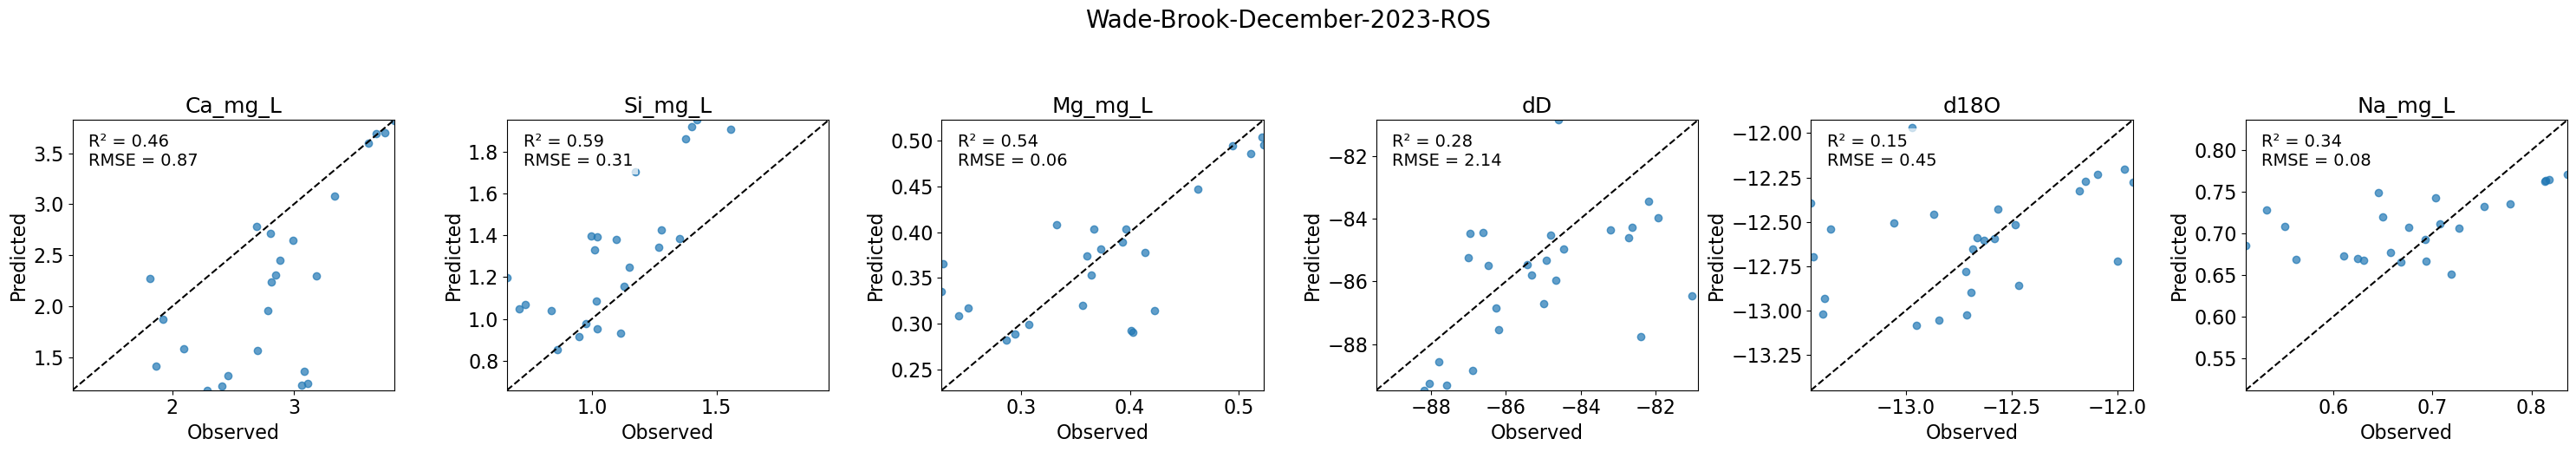

✅ Figure saved to output/EMMA-error-plots/Wade-Brook-December-2023-ROS.png


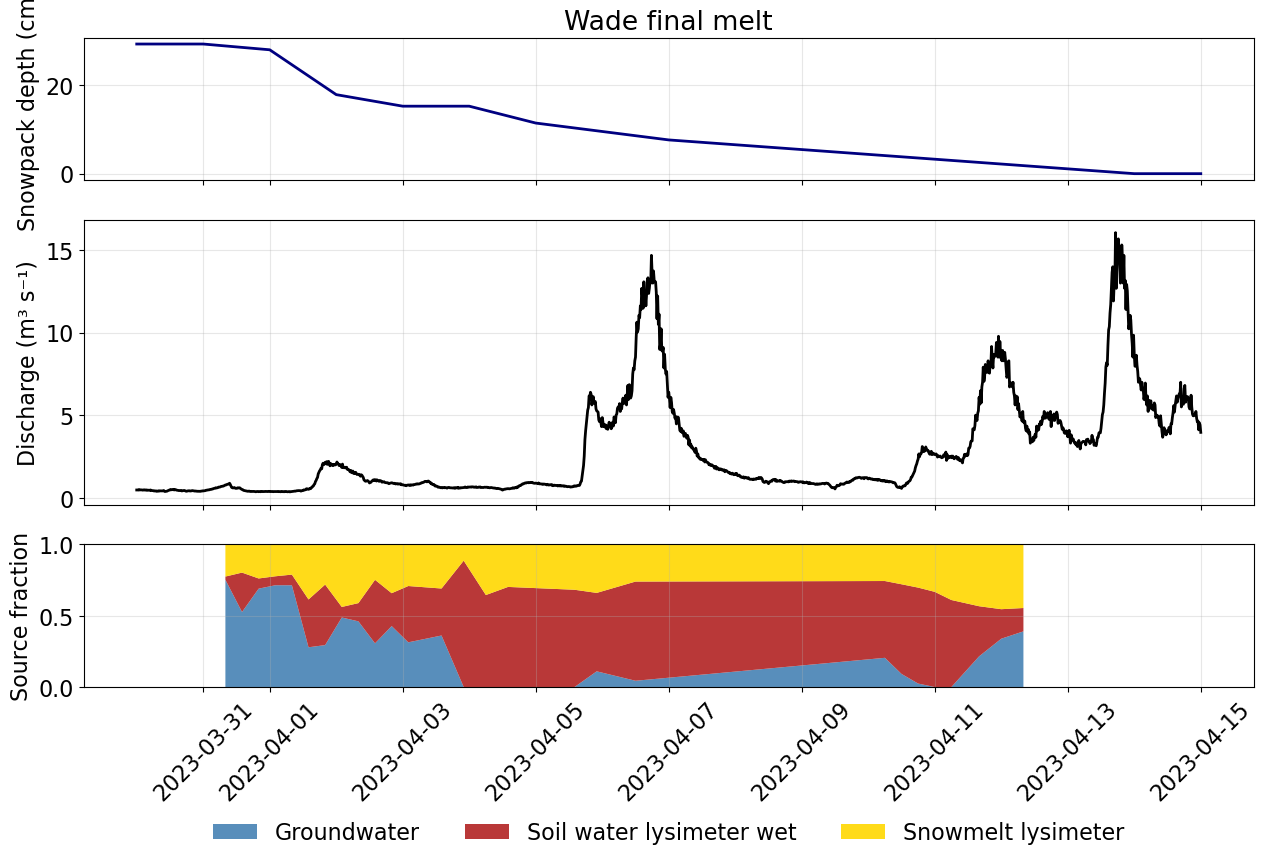

In [7]:
import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_emma as em
importlib.reload(em)

# Load the full RI25 dataset
df = pd.read_csv("/home/millieginty/OneDrive/git-repos/EMMA/data/newrnet-chemistry/RI23/RI23-IC-ICP-isotope-toc-joined-Wade.csv")

####################
# Wade RI23 events #
####################

# Event C
# Wade freshet
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5010 Precip 04/10
    # RI23-1098 Snowmelt lysimeter 4/11
    # RI23-5011 Soil water lysimeter wet 4/12
    # RI23-5012 Snowmelt lysimeter 4/12
    # RI23-1063 Snowmelt lysimeter 3/28

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_decros_fractions_df, wade_decros_scaler, wade_decros_pca, wade_decros_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-15 00:00:00",
    endmember_ids=["RI23-5018", "RI23-5006", # Groundwater samples from Wade wells
                   "RI23-1034", # Baseflow from 2023
                   "RI22-0860", "RI22-0859", # RI22 Groundwater samples
                   "RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # RI25 Baseflow samples
                   "RI23-5011", "RI23-1063", "RI23-5005"])

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']

# Call the prediction function
wade_decros_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_decros_fractions_df,
    endmembers_df=wade_decros_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted("Wade-Brook-December-2023-ROS", wade_decros_predicted, df, wade_tracers)

em.plot_emma_fractions_with_hydrograph(
    fractions_df= wade_decros_fractions_df,
    discharge_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    snowpack_csv="/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414.csv",
    snowpack_time_col="datetime",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-15 00:00:00",
    site="Wade",
    title="Wade final melt"
)